In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_excel("HousePricePrediction (1).xlsx")

print(dataset.head(5))

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [2]:
dataset.shape

(2919, 13)

In [3]:
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:",len(object_cols))

int_ = (dataset.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:",len(num_cols))

fl = (dataset.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:",len(fl_cols))

Categorical variables: 0
Integer variables: 6
Float variables: 3


<Axes: >

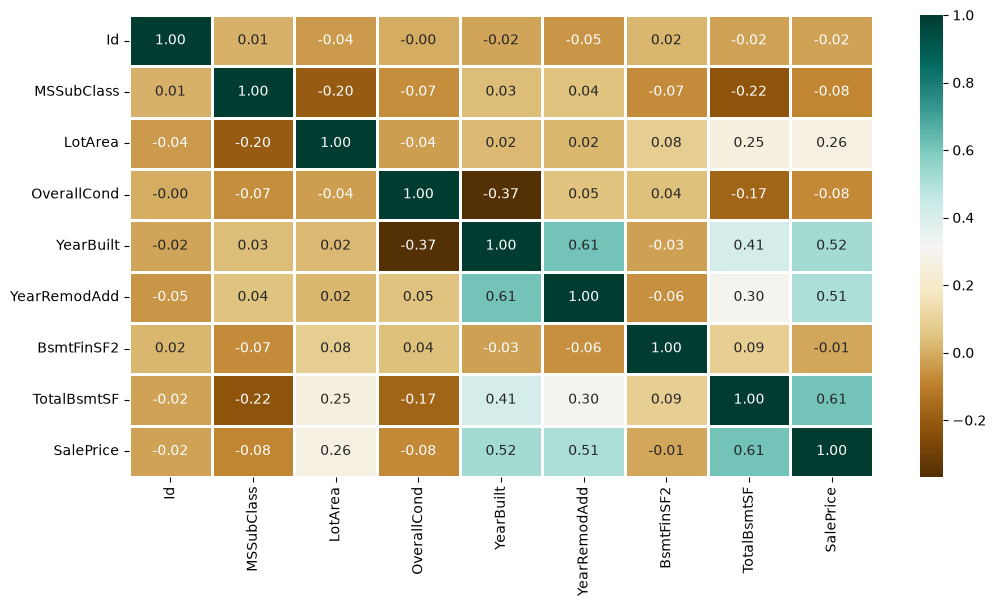

In [4]:
numerical_dataset = dataset.select_dtypes(include=['number'])

plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(),
            cmap = 'BrBG',
            fmt = '.2f',
            linewidths = 2,
            annot = True)

<Axes: title={'center': 'No. Unique values of Categorical Features'}>

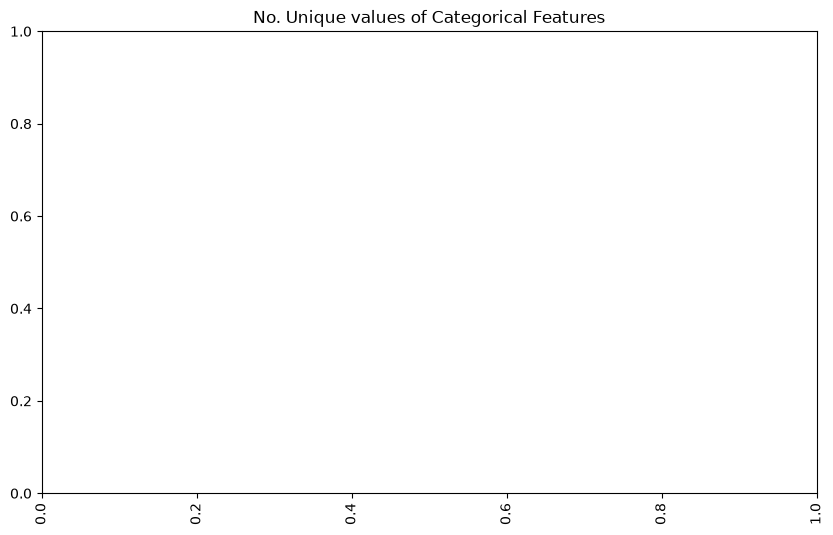

In [5]:
unique_values = []
for col in object_cols:
  unique_values.append(dataset[col].unique().size)
plt.figure(figsize=(10,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values)

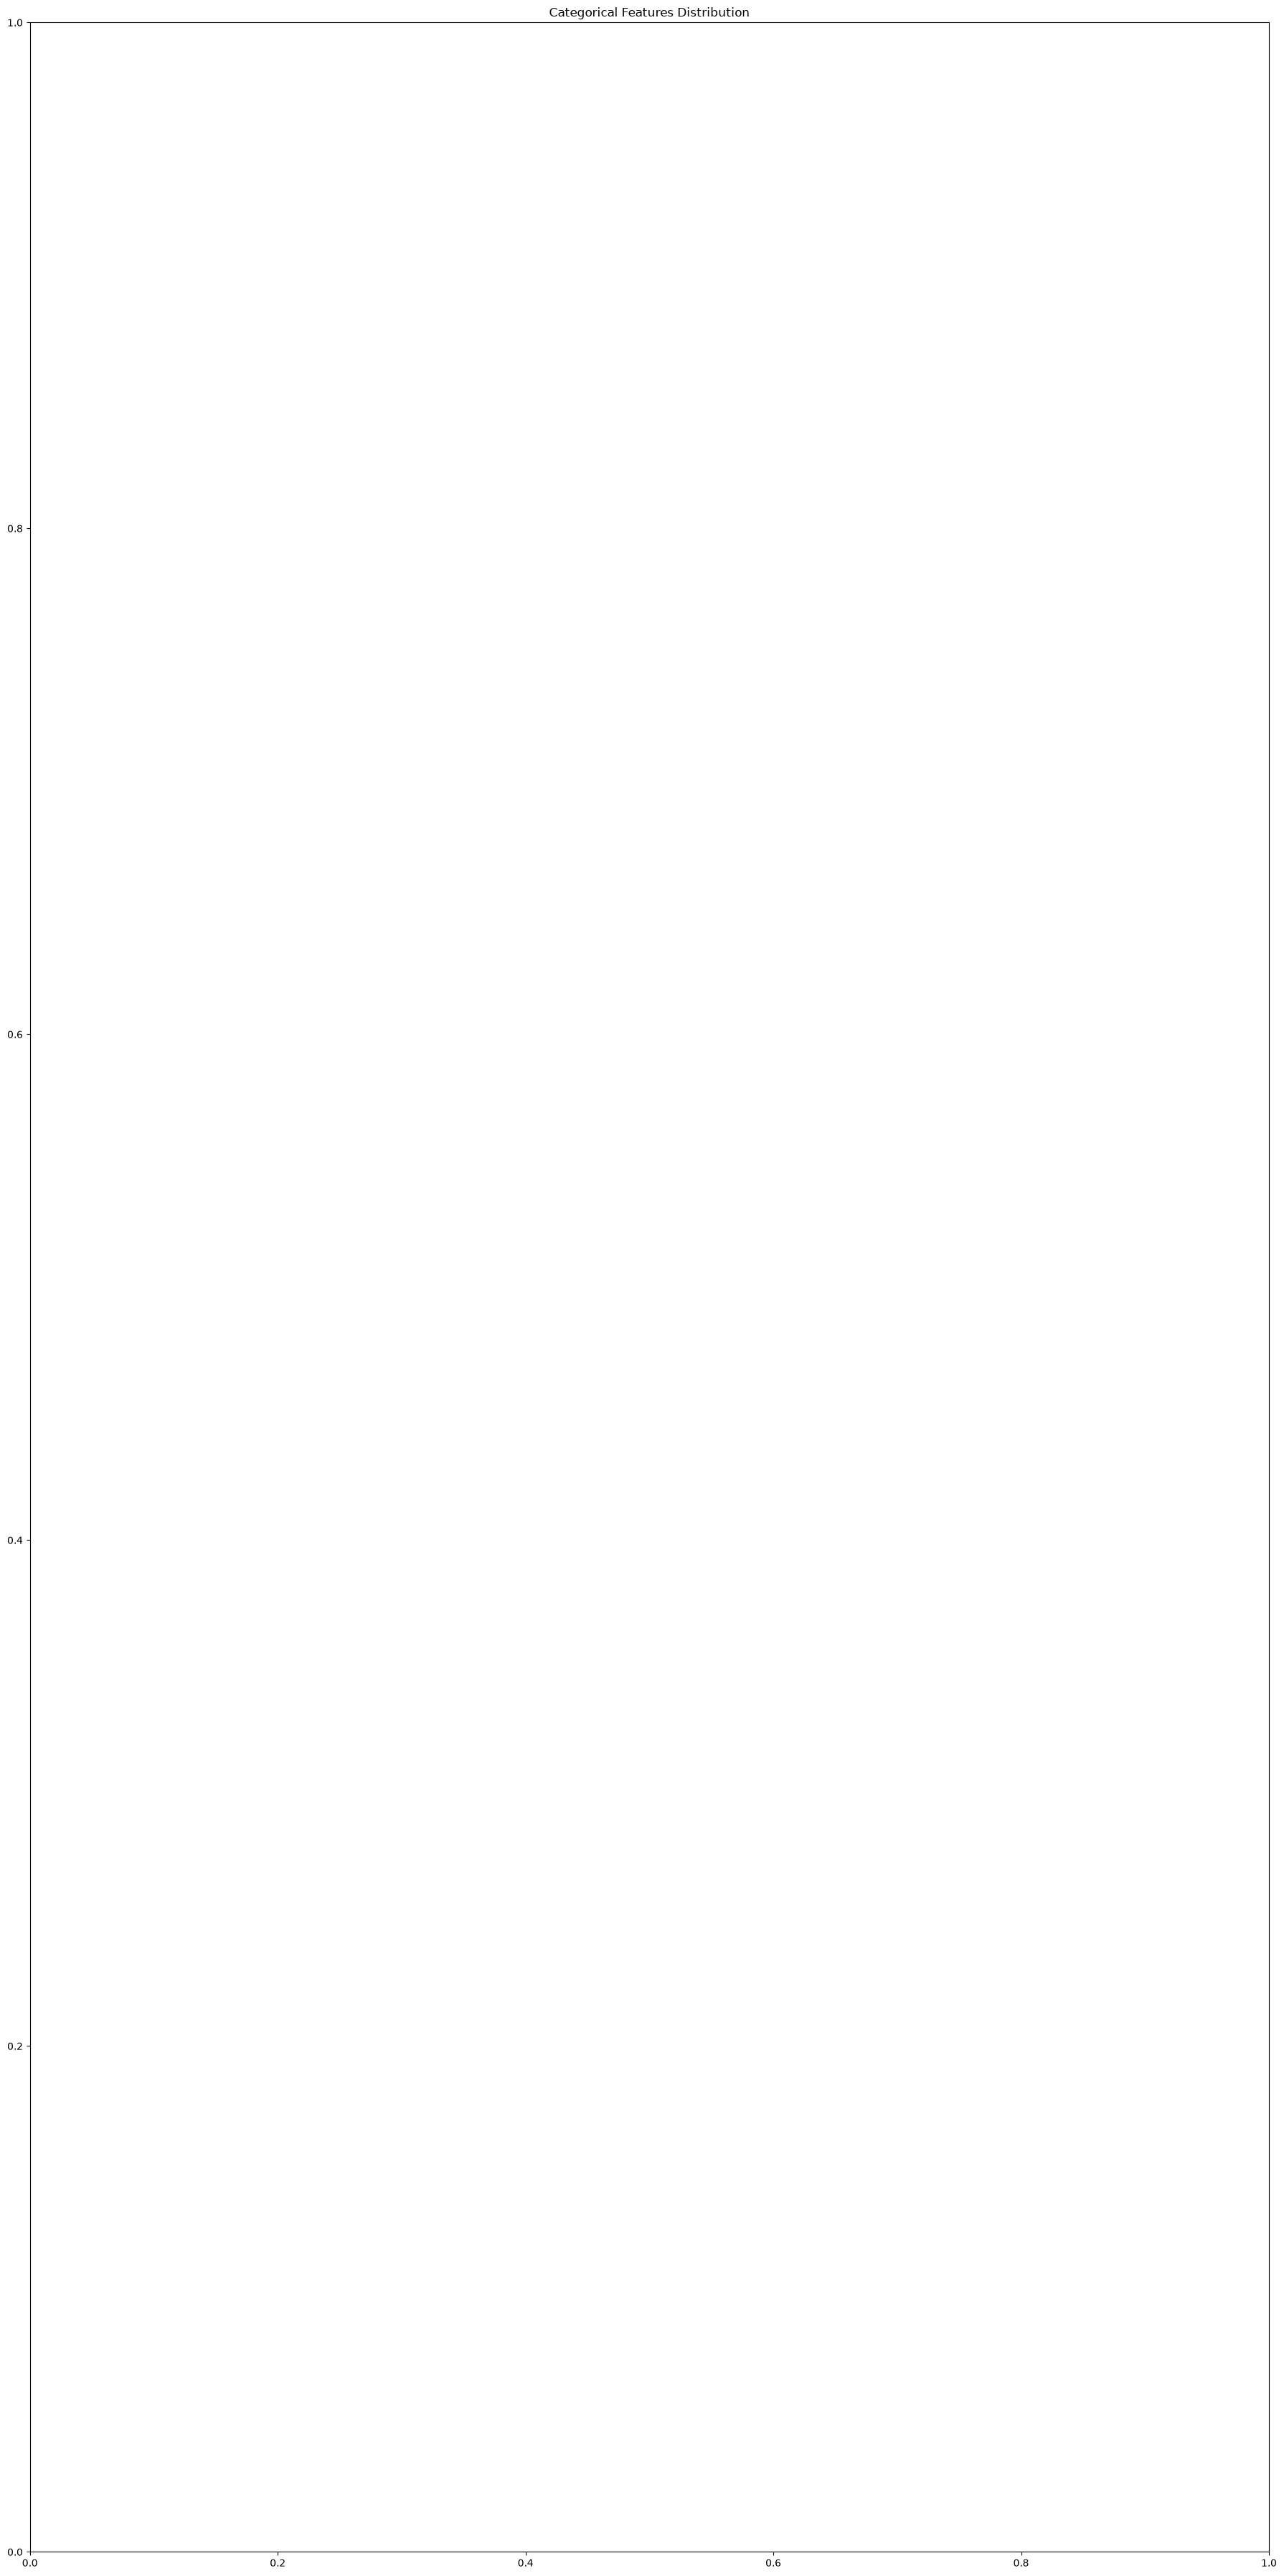

In [6]:
plt.figure(figsize=(18, 36))
plt.title('Categorical Features Distribution')
index = 1

for col in object_cols:
    y = dataset[col].value_counts()
    plt.subplot(11, 4, index)
    plt.xticks(rotation=90)
    sns.barplot(x=y.index, y=y.values)
    plt.xlabel(col)
    plt.ylabel("Count")
    index += 1

plt.tight_layout()
plt.show()

In [7]:
dataset.drop(['Id'],
             axis=1,
             inplace=True)

In [8]:
dataset['SalePrice'] = dataset['SalePrice'].fillna(
  dataset['SalePrice'].mean())

In [9]:
new_dataset = dataset.dropna()

In [10]:
new_dataset.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [11]:
from sklearn.preprocessing import OneHotEncoder

s = (new_dataset.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ',
      len(object_cols))

Categorical variables:
[]
No. of. categorical features:  0


In [12]:
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

In [13]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = df_final.drop(['SalePrice'], axis=1)
Y = df_final['SalePrice']

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=0)

In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = df_final.drop(['SalePrice'], axis=1)
Y = df_final['SalePrice']

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=0)

In [15]:
# Fix: Encode all string/categorical columns
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_valid[col] = le.transform(X_valid[col].astype(str))

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_percentage_error
from sklearn import svm
import pandas as pd
import numpy as np

# Convert ALL object columns to numeric using pandas
X_train_enc = X_train.copy()
X_valid_enc = X_valid.copy()

X_train_enc = pd.get_dummies(X_train_enc)
X_valid_enc = pd.get_dummies(X_valid_enc)

# Make both have same columns
X_train_enc, X_valid_enc = X_train_enc.align(X_valid_enc, join='left', axis=1, fill_value=0)

# Fill any remaining NaN
X_train_enc = X_train_enc.fillna(0)
X_valid_enc = X_valid_enc.fillna(0)

Y_train_flat = np.ravel(Y_train)
model_SVR = svm.SVR()
model_SVR.fit(X_train_enc, Y_train_flat)
Y_pred = model_SVR.predict(X_valid_enc)
print("MAPE:", mean_absolute_percentage_error(Y_valid, Y_pred))

MAPE: 0.187051293134216


In [20]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_valid[col] = le.transform(X_valid[col].astype(str))

In [21]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        
for col in X_valid.columns:
    if X_valid[col].dtype == 'object':
        X_valid[col] = le.fit_transform(X_valid[col].astype(str))

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_valid = X_valid.apply(pd.to_numeric, errors='coerce')

X_train = X_train.fillna(0)
X_valid = X_valid.fillna(0)

Y_train_flat = np.ravel(Y_train)

print("Done ✅")
print(X_train.dtypes)

Done ✅
MSSubClass        int64
MSZoning        float64
LotArea           int64
LotConfig       float64
BldgType        float64
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st     float64
BsmtFinSF2      float64
TotalBsmtSF     float64
dtype: object


In [22]:
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("Any NaN in X?", X_train.isnull().sum().any())
print("Any NaN in Y?", Y_train.isnull().sum().any())
print(X_train.dtypes)

X_train shape: (2330, 11)
Y_train shape: (2330,)
Any NaN in X? False
Any NaN in Y? False
MSSubClass        int64
MSZoning        float64
LotArea           int64
LotConfig       float64
BldgType        float64
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st     float64
BsmtFinSF2      float64
TotalBsmtSF     float64
dtype: object


In [23]:
import numpy as np
from sklearn import svm
from sklearn.metrics import mean_absolute_percentage_error

Y_train_flat = np.ravel(Y_train)
model_SVR = svm.SVR()
model_SVR.fit(X_train, Y_train_flat)
Y_pred = model_SVR.predict(X_valid)

print("MAPE:", mean_absolute_percentage_error(Y_valid, Y_pred))

MAPE: 0.18705129324281566


In [24]:
from sklearn.ensemble import RandomForestRegressor

model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_valid)

mean_absolute_percentage_error(Y_valid, Y_pred)

0.19327835074406763

In [25]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred = model_LR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.1879740075810429


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_RFR = RandomForestRegressor(n_estimators=10, random_state=42)
model_RFR.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [ ]:
print(hasattr(model_RFR, "estimators_"))

True


In [ ]:
print(X_train.columns)

Index(['MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'BsmtFinSF2', 'TotalBsmtSF', 'MSZoning_C (all)', 'MSZoning_FV',
       'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'LotConfig_Corner',
       'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3',
       'LotConfig_Inside', 'BldgType_1Fam', 'BldgType_2fmCon',
       'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE',
       'Exterior1st_AsbShng', 'Exterior1st_AsphShn', 'Exterior1st_BrkComm',
       'Exterior1st_BrkFace', 'Exterior1st_CBlock', 'Exterior1st_CemntBd',
       'Exterior1st_HdBoard', 'Exterior1st_ImStucc', 'Exterior1st_MetalSd',
       'Exterior1st_Plywood', 'Exterior1st_Stone', 'Exterior1st_Stucco',
       'Exterior1st_VinylSd', 'Exterior1st_Wd Sdng', 'Exterior1st_WdShing'],
      dtype='str')


In [ ]:
print(X_train.select_dtypes(include='object').columns)

Index(['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_8320\2510415556.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include='object').columns)


In [ ]:
X = pd.get_dummies(X, columns=['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [41]:
import pandas as pd

new_house = pd.DataFrame(0, index=[0], columns=X_train.columns)

In [34]:
from sklearn.ensemble import RandomForestRegressor

Y_train_flat = np.ravel(Y_train)
model_RFR = RandomForestRegressor()
model_RFR.fit(X_train_enc, Y_train_flat)
print("Done! Model now expects:", model_RFR.n_features_in_, "columns")

Done! Model now expects: 35 columns


In [40]:
import pandas as pd

new_house = pd.DataFrame(0, index=[0], columns=X_train_enc.columns)

new_house['MSSubClass'] = int(input("Enter MSSubClass: "))
new_house['LotArea'] = int(input("Enter Lot Area: "))
new_house['OverallCond'] = int(input("Enter Overall Condition: "))
new_house['YearBuilt'] = int(input("Enter Year Built: "))
new_house['YearRemodAdd'] = int(input("Enter Year Remodeled: "))
new_house['BsmtFinSF2'] = int(input("Enter Basement Finished Area 2: "))
new_house['TotalBsmtSF'] = int(input("Enter Total Basement Area: "))

predicted_price = model_RFR.predict(new_house)
print(f"\n Predicted House Price: ${predicted_price[0]:,.2f}")


 Predicted House Price: $195,817.11
